# Initialization

In [8]:
import stim
import random
import csv
import pandas as pd
import collections
import os
import json
import numpy as np

from qiskit import QuantumCircuit, transpile, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator, QasmSimulator, Aer

from qiskit_ibm_runtime import QiskitRuntimeService, Session, Options, Sampler, SamplerV2, RuntimeEncoder, RuntimeDecoder

from qiskit.visualization import plot_histogram, plot_circuit_layout, plot_state_city
from qiskit.circuit.classical import expr
from qiskit_aer.noise import (NoiseModel, QuantumError, ReadoutError, reset_error,
    pauli_error, depolarizing_error, thermal_relaxation_error)
import qiskit.quantum_info as qi
from qiskit.qasm2 import dumps
from qiskit.circuit.library import RZZGate, RZGate, XGate, IGate
from qiskit.converters import circuit_to_dag, dag_to_circuit
# from qiskit.transpiler.passes import ALAPScheduleAnalysis, ASAPScheduleAnalysis, PadDynamicalDecoupling, PadDelay, PassManager
from qiskit.qasm2 import dumps
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from wrappers.polar_wrapper import (
        polar_code_p2, get_logical_error_on_accepted_states, divide_half_list, get_logical_error_on_accepted_states_SCL,
    get_logical_error_on_accepted_states
)

from wrappers.stim_wrapper import (
    convert_i_to_meas_type, generate_circuit_extraction_syndrome_stim, simulate_stim_polar_code, noisy_cx, noisy_h, noisy_x, noisy_z, 
    noisy_reset, noisy_measurement, calculate_logical_error_result_polar, create_circuit_polar_stim_normal,
    generate_circuit_extraction_syndrome_stim_normal, simulate_stim_polar_code_normal

    
)

# token = "23OwipXqZzd8plKZR2LDMK-peWuU74UQAyjAhMIaFHCM"
# QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token=token, instance="free", overwrite=True)
# service = QiskitRuntimeService(channel="ibm_quantum_platform", token=token, instance="free")
# # service = QiskitRuntimeService()
# # hw_name = "ibm_brisbane"
# hw_name = "ibm_marrakesh"
# backend = service.backend(hw_name)

# sim_ideal = AerSimulator()
# sim_noisy = AerSimulator.from_backend(backend)

# ## change later back to 3
# pm = generate_preset_pass_manager(
#     optimization_level=3, backend=backend
#     #, seed_transpiler=12345
#     )

def get_backend_information(backend):

    properties = backend.properties()
    num_qubits = backend.num_qubits
    coupling_map = backend.coupling_map

    # We define various lists of metrics for all the qubits of the backend
    t1, t2, gate_error_x, readout_error, gate_error_cz = {}, {}, {}, {}, {}
    for i in range(num_qubits):
        # t1.append(properties.t1(i))
        # t2.append(properties.t2(i))
        # gate_error_x.append(properties.gate_error(gate="x", qubits=i))
        # readout_error.append(properties.readout_error(i))
        t1[i] = properties.t1(i)
        t2[i] = properties.t2(i)
        gate_error_x[i] = properties.gate_error(gate="x", qubits=i)
        readout_error[i] = properties.readout_error(i)

    for pair in coupling_map:
        gate_error_cz[pair] = properties.gate_error(gate="cz", qubits=pair)

    
    return t1, t2, gate_error_x, readout_error, gate_error_cz

print("stim version :", stim.__version__)
sim = stim.TableauSimulator()

import itertools
import logging
import random
from concurrent.futures import ProcessPoolExecutor
from wrappers.polar_wrapper import (
    polar_code_p2, get_logical_error_on_accepted_states, divide_half_list
)
from wrappers.stim_wrapper import (
    calculate_logical_error_result_polar_normal,
    simulate_batch_and_save_result_polar_normal,
    generate_qiskit_polar_code, compiled_to_qiskit_hardware,
    find_and_delete_files
)

import pandas as pd
import os
import glob
import sys

from qiskit_ibm_runtime import QiskitRuntimeService



stim version : 1.15.0


# Proposal

## Normal way


In [9]:
n, lstate, sim_type, p_error, i, shots, seed, decoder = 4, "x", "m1", 0.005, 6, 100, 123456, "val"

result = simulate_batch_and_save_result_polar_normal(n, lstate, sim_type, p_error, i, shots, seed, decoder)
result

{'n': 4,
 'lstate': 'x',
 'i': 6,
 'meas_type': ['x', 'x', 'z', 'x'],
 'p_error': 0.005,
 'sim_type': 'm1',
 'decoder_type': 'val',
 'total_meta_shots': 0,
 'shots': 100,
 'count_accept': 52,
 'count_logerror': 0,
 'count_undecided': 1,
 'count_detect_discard': 0,
 'prep_rate': 0.52,
 'LER': 0.0,
 'detect_normal': 0,
 'decoding_normal': 0.03710228390991688}

## New protocol

In [10]:
n, lstate, sim_type, p_error, i, shots, seed, decoder = 4, "x", "m1", 0.005, 6, 100, 123456, "val"
t1, t2, error_1q, readout_error, error_2q = None, None, None, None, None
cm = None
initial_layout = None
meas_type = convert_i_to_meas_type(i, n, lstate)
N = 2**n
ancilla_qubits = 2**(n - 1)
total_qubits = N + ancilla_qubits

x_ind = 0
for idx, m_type in enumerate(meas_type):
    if m_type == "x":
        x_ind = idx
        break

print(meas_type)

['x', 'x', 'z', 'x']


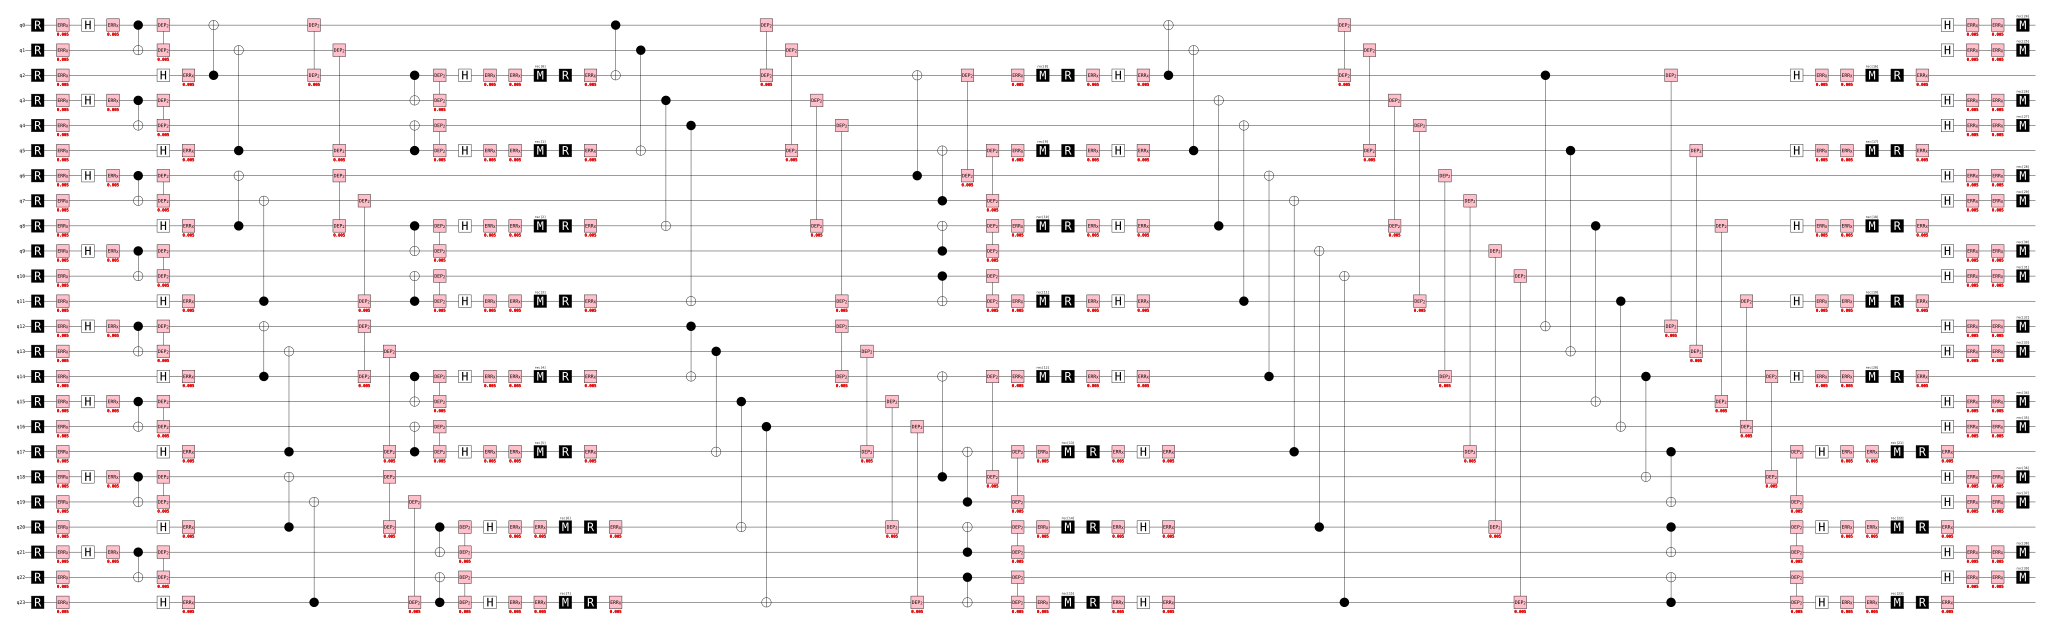

In [11]:
circuit = create_circuit_polar_stim_normal(n, lstate, sim_type, p_error, seed, shots, 
                           error_1q, readout_error, error_2q,
                           meas_type, total_qubits, x_ind,
                           cm = cm, initial_layout = initial_layout
                            )
circuit.diagram("timeline-svg")

In [12]:
def generate_circuit_extraction_syndrome_stim_normal_update(circuit: stim.Circuit, k, meas_type, x_first = False, p_error = 0, start_idx_list = [0],
                                              error_1q = None, error_2q = None, readout_error = None, initial_layout = None, cm=None,
                                              apply_cnot_list = []
                                              ):
    
    num_qbits = (2**k) + (2**(k-1))
    num_cbits = 2**(k-1)
    h_1 = []
    h_2 = []
    cnot_1 = []
    cnot_2 = []
    m = []
    r = []

    for start_idx in start_idx_list:
        data_qubits = []
        ancillas = []
    
        for idx in range(2**(k-1)):
            ancillas.append(idx * 3 + 2 + start_idx) 

        for idx in range(start_idx, num_qbits + start_idx):
            if idx not in ancillas:
                data_qubits.append(idx) 

        d1, d2 = divide_half_list(data_qubits)

        for idx in range(len(d1)):

            if meas_type.lower() == "x":

                if x_first:
                    h_1.append(d1[idx])
                    cnot_1.append(d1[idx])
                    cnot_1.append(d2[idx])

                else:
                    h_1.append(ancillas[idx])
                    cnot_1.append(ancillas[idx])
                    cnot_1.append(d1[idx])
                    cnot_2.append(ancillas[idx])
                    cnot_2.append(d2[idx])
                    h_2.append(ancillas[idx])
                    m.append(ancillas[idx])
                    r.append(ancillas[idx])

            elif meas_type.lower() == "z":
                cnot_1.append(d1[idx])
                cnot_1.append(ancillas[idx])
                cnot_2.append(d2[idx])
                cnot_2.append(ancillas[idx])
                m.append(ancillas[idx])
                r.append(ancillas[idx])

    for add_start_idx in apply_cnot_list:
        add_data_qubits = []
        add_ancillas = []

        for idx in range(2**(k-1)):
            add_ancillas.append(idx * 3 + 2 + add_start_idx) 

        for idx in range(add_start_idx, num_qbits + add_start_idx):
            if idx not in add_ancillas:
                add_data_qubits.append(idx) 

        ad1, ad2 = divide_half_list(add_data_qubits)
        print("masuk", add_start_idx, k, ad1, ad2, add_ancillas)

        noiseless_m = []
        noiseless_r = []
        for idx in add_ancillas:
            noiseless_m.append(idx)
            noiseless_r.append(idx)
            
        for idx in range(len(ad1)):
            h_1.append(ad1[idx])
            cnot_1.append(ad1[idx])
            cnot_1.append(ad2[idx])

        for idx in add_ancillas:
            m.append(idx)
            r.append(idx)

        # # Note: jump 6 at part 3
        # noisy_h(sim, 12, p=p_error)
        # noisy_cx(sim, 12, 18, p=p_error)
        # noisy_h(sim, 13, p=p_error)
        # noisy_cx(sim, 13, 19, p=p_error)
        # noisy_h(sim, 15, p=p_error)
        # noisy_cx(sim, 15, 21, p=p_error)
        # noisy_h(sim, 16, p=p_error)
        # noisy_cx(sim, 16, 22, p=p_error)

        if len(noiseless_m) > 0: 
            circuit.append("R", noiseless_r)
            circuit.append("M", noiseless_m)
            circuit.append("R", noiseless_r)


    if len(h_1) > 0: 
        circuit.append("H", h_1)

        if error_1q != None:
            for idx in h_1:
                pq_targ = initial_layout[idx]
                error_rate = error_1q[pq_targ] * p_error
                circuit.append("X_ERROR", idx, error_rate)    
        else:
            circuit.append("X_ERROR", h_1, p_error)

    if len(cnot_1) > 0: 
        circuit.append("CNOT", cnot_1)

        if error_2q != None:
            for ctrl, targ in zip(cnot_1[::2], cnot_1[1::2]):
                # pq = physical qubit
                pq_ctrl = initial_layout[ctrl]
                pq_targ = initial_layout[targ]

                path = cm.shortest_undirected_path(pq_ctrl, pq_targ)
                path_pairs = list(zip(path[:-1], path[1:]))

                fid_total = 1
                for pair in path_pairs:
                    fid_total *= (1 - error_2q[pair])

                error_rate = (1 - fid_total) * p_error

                circuit.append("DEPOLARIZE2", [ctrl, targ], error_rate)
        else:
            circuit.append("DEPOLARIZE2", cnot_1, p_error)

    
    if len(cnot_2) > 0: 
        circuit.append("CNOT", cnot_2)

        if error_2q != None:
            for ctrl, targ in zip(cnot_2[::2], cnot_2[1::2]):
                # pq = physical qubit
                pq_ctrl = initial_layout[ctrl]
                pq_targ = initial_layout[targ]

                path = cm.shortest_undirected_path(pq_ctrl, pq_targ)
                path_pairs = list(zip(path[:-1], path[1:]))

                fid_total = 1
                for pair in path_pairs:
                    fid_total *= (1 - error_2q[pair])

                error_rate = (1 - fid_total) * p_error

                circuit.append("DEPOLARIZE2", [ctrl, targ], error_rate)
        else:
            circuit.append("DEPOLARIZE2", cnot_2, p_error)

    if len(h_2) > 0: 
        circuit.append("H", h_2)

        if error_1q != None:
            for idx in h_2:
                pq_targ = initial_layout[idx]
                error_rate = error_1q[pq_targ] * p_error
                circuit.append("X_ERROR", idx, error_rate)    
        else:
            circuit.append("X_ERROR", h_2, p_error)

    if len(m) > 0: 
        if error_1q != None:
            for idx in m:
                pq_targ = initial_layout[idx]
                error_rate = error_1q[pq_targ] * p_error
                circuit.append("X_ERROR", idx, error_rate)    
        else:
            circuit.append("X_ERROR", m, p_error)

        circuit.append("M", m)

    if len(r) > 0: 
        circuit.append("R", r)
        if error_1q != None:
            for idx in r:
                pq_targ = initial_layout[idx]
                error_rate = error_1q[pq_targ] * p_error
                circuit.append("X_ERROR", idx, error_rate)    
        else:
            circuit.append("X_ERROR", r, p_error)

In [ ]:
def create_circuit_polar_stim_normal_update(n, lstate, sim_type, p_error, seed, shots, 
                           error_1q, readout_error, error_2q,
                           meas_type, total_qubits, x_ind,
                           cm = None, initial_layout = None
                            ):

    circuit = stim.Circuit()

    # initialization error
    r_start = []
    for idx in range(total_qubits):
        r_start.append(idx)

    circuit.append("R", r_start)
    if error_1q != None:
        for idx in r_start:
            pq_targ = initial_layout[idx]
            error_rate = error_1q[pq_targ] * p_error
            circuit.append("X_ERROR", idx, error_rate)    
    else:
        circuit.append("X_ERROR", r_start, p_error)

    for level in range(1, n+1):

        # print(level, "-", meas_type[level - 1])
        
        num_loops = 2**(n - level)
        start_idx_mult = 2**(level) + 2**(level - 1)

        if sim_type in ["m1", "m2", "m3"] and level == x_ind + 1:
            x_first = True
        else:
            x_first = False

        if level <= x_ind:
            # skip the beginning of zz measurement
            print("skip :" , level, x_ind)
            pass
        else:
            
            start_idx_list = []

            if level < n - 1:
                num_loops = int(num_loops / 2)

            for loop_idx in range(num_loops):
                start_idx = loop_idx * start_idx_mult
                start_idx_list.append(start_idx)
            
            apply_cnot_list = []
            if level == n - 1:
                apply_cnot_list = start_idx_list[len(start_idx_list)//2:]
                start_idx_list = start_idx_list[:len(start_idx_list)//2]


            print("meas_type:", meas_type, level-1, num_loops, start_idx_list, apply_cnot_list)

            apply_cnot = False
            

            generate_circuit_extraction_syndrome_stim_normal_update(circuit, level, meas_type[level - 1], x_first, p_error=p_error, start_idx_list=start_idx_list,
                                                        error_1q=error_1q, error_2q=error_2q, readout_error=readout_error, initial_layout=initial_layout, cm=cm, apply_cnot_list=apply_cnot_list)
              
        
    # Final measurements
    h_last = []
    m_last = []
    for qb_idx in (j for j in range(total_qubits) if j % 3 != 2):
        if lstate.lower() == "x":
            h_last.append(qb_idx)
        m_last.append(qb_idx)
        
    circuit.append("H", h_last)
    if error_1q != None:
        for idx in h_last:
            pq_targ = initial_layout[idx]
            error_rate = error_1q[pq_targ] * p_error
            circuit.append("X_ERROR", idx, error_rate)    
    else:
        circuit.append("X_ERROR", h_last, p_error)

    if error_1q != None:
        for idx in m_last:
            pq_targ = initial_layout[idx]
            error_rate = error_1q[pq_targ] * p_error
            circuit.append("X_ERROR", idx, error_rate)    
    else:
        circuit.append("X_ERROR", m_last, p_error)
    circuit.append("M", m_last) 
    

    # circuit = add_stim_error(circuit, p_error)
    # circuit.diagram("timeline-svg")

    return circuit


meas_type: ['x', 'x', 'z', 'x'] 0 4 [0, 3, 6, 9] []
meas_type: ['x', 'x', 'z', 'x'] 1 2 [0, 6] []
meas_type: ['x', 'x', 'z', 'x'] 2 2 [0] [12]
masuk 12 3 [12, 13, 15, 16] [18, 19, 21, 22] [14, 17, 20, 23]
meas_type: ['x', 'x', 'z', 'x'] 3 1 [0] []


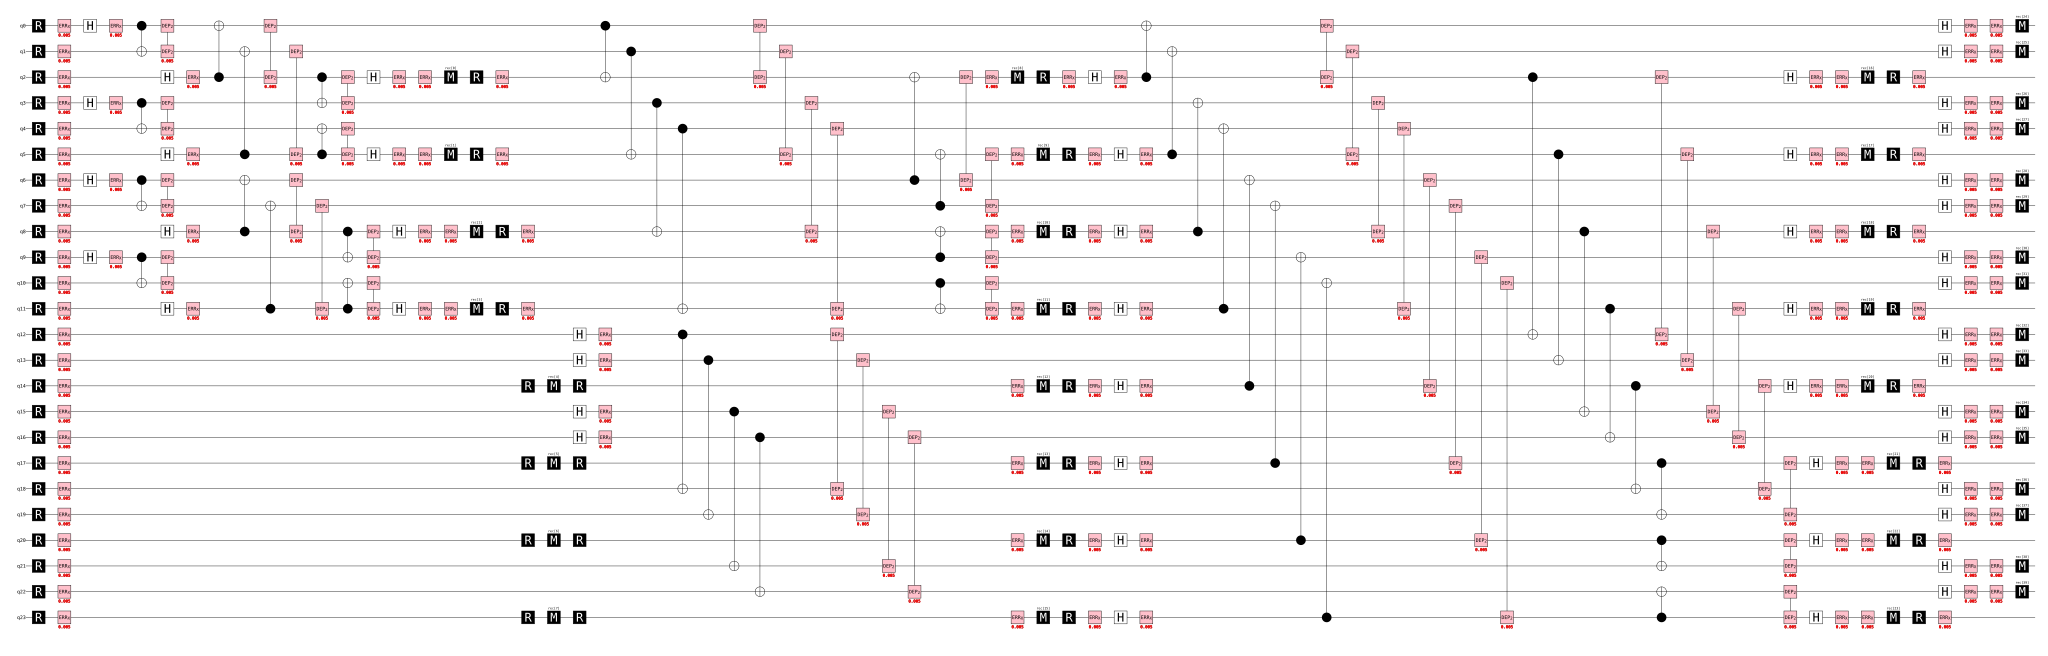

In [14]:
circuit = create_circuit_polar_stim_normal_update(n, lstate, sim_type, p_error, seed, shots, 
                           error_1q, readout_error, error_2q,
                           meas_type, total_qubits, x_ind,
                           cm = cm, initial_layout = initial_layout
                            )
circuit.diagram("timeline-svg")

### Apply the proposal = Getting result

In [ ]:
def simulate_stim_polar_code_normal_update(n, lstate, sim_type, i, p_error, shots, seed, backend = None, initial_layout = None):
    """
    Simulates a quantum circuit for stabilizer code, simplified and optimized.

    Args:
        n (int): code length for polar code
        lstate (str): z for logical |0>, z for logical |+>
        sim_type: normal, m1, m2, m3
        p_error (float): The probability of an error occurring.
        shots (int): The number of simulation runs.
        seeds (list): A list of seeds for the simulator.
        i (int): An index used to determine measurement types (message location)

    Returns:
        dict: A dictionary of measurement outcome counts.
    """
    #m1 circuit simplify
    #m2 m1 + error detection
    #m3 m1 + error correction
    
    if backend != None:
        t1, t2, error_1q, readout_error, error_2q = get_backend_information(backend)
        cm = backend.coupling_map
    else:
        t1, t2, error_1q, readout_error, error_2q = None, None, None, None, None
        cm = None

    meas_type = convert_i_to_meas_type(i, n, lstate)
    N = 2**n
    ancilla_qubits = 2**(n - 1)
    total_qubits = N + ancilla_qubits

    x_ind = 0
    for idx, m_type in enumerate(meas_type):
        if m_type == "x":
            x_ind = idx
            break

    circuit = create_circuit_polar_stim_normal_update(n, lstate, sim_type, p_error, seed, shots, 
                           error_1q, readout_error, error_2q,
                           meas_type, total_qubits, x_ind,
                           cm = cm, initial_layout = initial_layout
                            ) 
    
    sampler = circuit.compile_sampler(seed=seed)
    results = sampler.sample(shots=int(shots) )

    counts = {}
    for res in results:
        bit_string = ""
        for j in res:
            if j:
                bit_string = "1" + bit_string 
            else:
                bit_string = "0" + bit_string

        if sim_type in ["m1", "m2", "m3"]:
            bit_string = bit_string + "0"*(2**(n - 1))

        if bit_string in counts:
            counts[bit_string] = counts[bit_string] + 1
        else:
            counts[bit_string] = 1   
    
    return counts

In [16]:
counts_update = simulate_stim_polar_code_normal_update(n, lstate, sim_type, i, p_error, shots, seed)
counts_normal = simulate_stim_polar_code_normal(n, lstate, sim_type, i, p_error, shots, seed)

# 11100011001111001101111100001010111100000000
print(len("111000110011110011011111000000001010111100000000"), len("001110001110000001001000001110100011111100000000"))
# def simulate_stim_polar_code_normal_update(n, lstate, sim_type, i, p_error, shots, seed, backend = None, initial_layout = None):

meas_type: ['x', 'x', 'z', 'x'] 0 4 [0, 3, 6, 9] []
meas_type: ['x', 'x', 'z', 'x'] 1 2 [0, 6] []
meas_type: ['x', 'x', 'z', 'x'] 2 2 [0] [12]
masuk 12 3 [12, 13, 15, 16] [18, 19, 21, 22] [14, 17, 20, 23]
meas_type: ['x', 'x', 'z', 'x'] 3 1 [0] []
48 48


### Calculate LER

In [17]:
from Decoders.SCL import PyDecoderPolarSCL 

def simulate_batch_and_save_result_polar_normal_update(n, lstate, sim_type, p_error, i, shots, seed, decoder_type="val"):

    zpos_list = [-1, -1, 1, 3, 6, 7, 22, 15, 90, 31, 362]
    zpos_list[n] = i-1

    results = simulate_stim_polar_code_normal_update(n, lstate, sim_type, i, p_error, shots, seed)

    counts = results
    total_shots = sum(counts.values())

    zpos_list = [-1, -1, 1, 3, 6, 7, 22, 15, 90, 31, 362]
    zpos_list[n] = i - 1

    if decoder_type == "val":
        count_accept, count_logerror, count_undecided, ler, detect_normal, decoding_normal = \
            get_logical_error_on_accepted_states(
                n, lstate.upper(), counts, zpos_list
            )
    else:

        frozen_bits_mask = np.ones(2**n, dtype=np.int32)
        frozen_bits_mask[i-1] = 0
        frozen_bits_mask = list(frozen_bits_mask)
        decoder = PyDecoderPolarSCL(1, 2**n, 1, frozen_bits_mask)

        count_accept, count_logerror, count_undecided, ler, detect_normal, decoding_normal = \
            get_logical_error_on_accepted_states_SCL(
                n, lstate.upper(), counts, decoder, p_error,zpos_list, 
            )

    # print(n, lstate, i, p_error, sim_type, count_accept)
    # Return structured result
    return {
        "n": n,
        "lstate": lstate,
        "i": i,
        "meas_type": meas_type,
        "p_error": p_error,
        "sim_type": sim_type,
        "decoder_type": decoder_type,
        "total_meta_shots": 0,
        "shots": total_shots,
        "count_accept": count_accept,
        "count_logerror": count_logerror,
        "count_undecided": count_undecided,
        "count_detect_discard": 0,
        "prep_rate": count_accept / (total_shots - 0),
        "LER": 1 - ler,
        "detect_normal": detect_normal,
        "decoding_normal": decoding_normal,
    }

In [18]:
n, lstate, sim_type, p_error, i, shots, seed, decoder = 4, "x", "m1", 0.0075, 6, 500000, 98776432, "val"

result = simulate_batch_and_save_result_polar_normal(n, lstate, "normal", p_error, i, shots, seed, decoder)
result_update = simulate_batch_and_save_result_polar_normal_update(n, lstate, "m1", p_error, i, shots, seed, decoder)

# def simulate_batch_and_save_result_polar_normal(n, lstate, sim_type, p_error, i, shots, seed, decoder_type="val"):

meas_type: ['x', 'x', 'z', 'x'] 0 4 [0, 3, 6, 9] []
meas_type: ['x', 'x', 'z', 'x'] 1 2 [0, 6] []
meas_type: ['x', 'x', 'z', 'x'] 2 2 [0] [12]
masuk 12 3 [12, 13, 15, 16] [18, 19, 21, 22] [14, 17, 20, 23]
meas_type: ['x', 'x', 'z', 'x'] 3 1 [0] []


In [19]:
LER_error = (result["count_logerror"] - (result["count_undecided"] / 2) ) / result["count_accept"] 
LER_error_update = (result_update["count_logerror"] - (result_update["count_undecided"] / 2) ) / result_update["count_accept"]


print(LER_error, LER_error_update, result["count_accept"], result_update["count_accept"], (LER_error - LER_error_update) / LER_error)

0.00016705037631893865 0.00018765922600994783 164621 263776 -0.12336907072667717


In [20]:
LER_error - (LER_error * (LER_error - LER_error_update) / LER_error)

0.00018765922600994783

In [21]:
LER_undecided = result["count_undecided"] / result["count_accept"] 
LER_undecided_update = result_update["count_undecided"] / result_update["count_accept"] 

print(LER_undecided, LER_undecided_update)

0.011401947503659922 0.011710693922115734


In [22]:
def simulate_n4_6_x_normal(p_error, shots, seeds):

    counts = {}
    bitstrings = []
    # p_error = 0.0001
    # shots = 100000
    
    sim = stim.TableauSimulator(seed=seeds[i])

    for i in range(8):
        start_idx = i * 3 
        generate_circuit_extraction_syndrome_stim(sim, 1, "x", False, p_error=p_error, start_idx=start_idx)
        generate_circuit_extraction_syndrome_stim_normal(circuit, level, meas_type[level - 1], x_first, p_error=p_error, start_idx_list=start_idx_list,
                                                    error_1q=error_1q, error_2q=error_2q, readout_error=readout_error, initial_layout=initial_layout, cm=cm)
    

    for qb in range(2, 24, 3): 
        noisy_measurement(sim, qb, p_error)
        noisy_reset(sim, qb, p_error)

    for i in range(4):
        start_idx = i * 6 
        generate_circuit_extraction_syndrome_stim(sim, 2, "x", False, p_error=p_error, start_idx=start_idx)

    for qb in range(2, 24, 3): 
        noisy_measurement(sim, qb, p_error)
        noisy_reset(sim, qb, p_error)

    for i in range(2):
        start_idx = i * 12 
        generate_circuit_extraction_syndrome_stim(sim, 3, "z", False, p_error=p_error, start_idx=start_idx)

    for qb in range(2, 24, 3): 
        noisy_measurement(sim, qb, p_error)
        noisy_reset(sim, qb, p_error)
        
    for i in range(1):
        start_idx = i * 24 
        generate_circuit_extraction_syndrome_stim(sim, 4, "x", False, p_error=p_error, start_idx=start_idx)

    for qb in range(2, 24, 3): 
        noisy_measurement(sim, qb, p_error)
        noisy_reset(sim, qb, p_error)

    for i in (j for j in range(24) if j % 3 != 2):
        noisy_h(sim, i, p_error)
        noisy_measurement(sim, i, p_error)

    # final_measurements = sim.measure_many(0, 1, 2)

    final_measurements = sim.current_measurement_record()

    bit_string = ''.join(['1' if b else '0' for b in final_measurements])
    # bit_string = "00000000" + bit_string
    bit_string = bit_string[::-1]
    # print(final_measurements, bit_string )

    if bit_string in counts:
        counts[bit_string] += 1
    else:
        counts[bit_string] = 1
    bitstrings.append(bit_string)

    return circuit


In [14]:
for i in range(1, 4):
    print(i)

1
2
3
